In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader,WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
from langchain_core.tools import tool
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain.agents import create_agent


c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_weather =ChatOpenAI()
model_crime_report =ChatOpenAI()
model_supervisor =ChatOpenAI()

In [3]:
import requests
import http.client
import json
from langchain_community.tools import DuckDuckGoSearchRun
@tool
def getweahter(city:str)->dict:
     """"this function is to get weather report for a given city anyhwere in the world"""
     url = f'https://api.weatherstack.com/forecast?access_key=ec07421f5107d04ec9fa783c8fcfd6c5&query={city}'
     response = requests.get(url)
     return response.json()
@tool
def getcrime(city:str)->str:
     """"this function is to crime related news for a given city ,Please search over internet and get me the crime report news content"""
     
     conn = http.client.HTTPSConnection("real-time-news-data.p.rapidapi.com")

     headers = {
     'x-rapidapi-key': "64bf35c7b0mshdffa12c25d62d35p1927fejsn6b5b49ce1713",
     'x-rapidapi-host': "real-time-news-data.p.rapidapi.com"
     }
     url=f'/search?query={city}&limit=3&time_published=anytime&country=IN&lang=en'
     conn.request("GET", url, headers=headers)

     res = conn.getresponse()
     data = res.read()

     #print(data.decode("utf-8"))
     s=[]
     if json.loads(data.decode("utf-8"))['status']=='OK':
          for i in json.loads(data.decode("utf-8"))['data']:

               s.append(i['snippet'])
          news='/n '.join (s)
     else:
          news='No crime news in the city recently'
     return news

In [4]:
#weather_prompt=SystemMessage(content="""you are weather assistant who provides the detail weather report for a city""")
weather_prompt="""you are weather assistant who provides the detail weather report for a city"""
#weather_agent=create_react_agent(model=model_weather,tools=[getweahter],prompt=weather_prompt,name='weather_agent')
weather_agent=create_agent(model_weather,tools=[getweahter],system_prompt=weather_prompt,name="weather_agent")

In [37]:
crime_prompt="""you are crime reporter who provides the detail crime news report related to tourist in a given city recently """
#crime_agent=create_react_agent(model=model_crime_report,tools=[getcrime],prompt=crime_prompt,  name="crime_agent")
#crime_agent=create_agent(model=model_crime_report,tools=[getcrime],system_prompt=crime_prompt,  name="crime_agent")
crime_agent=create_agent(model=model_crime_report,tools=[getcrime],system_prompt=crime_prompt,  name="crime_agent")

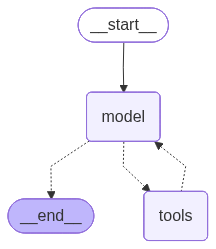

In [39]:
crime_agent

In [12]:
#ques="Can you get me the crime news of lucknow"
#messages = crime_agent.invoke({"messages": [HumanMessage(content=ques)]})

In [40]:
@tool
def supervisor()->str:
    """"You are a Supervisor coordinating two specialists:

- weather_agent: finds weather of a city.
- crime_agent: given a city  list down the all the crime related news only."""
    return ''
supervisor_system_message = """
You are a Supervisor coordinating two specialists:

- weather_agent: finds weather of a city.
- crime_agent: given a city  list down the all the crime related news only.

Your goal is recommend is it safe to travel to a city with respect to weather and crime related for a new tourist"""



In [44]:
supervisor=create_supervisor(
    agents=[crime_agent, weather_agent],
    model=model_supervisor,
    prompt=supervisor_system_message,
  
    output_mode="full_history"
).compile()

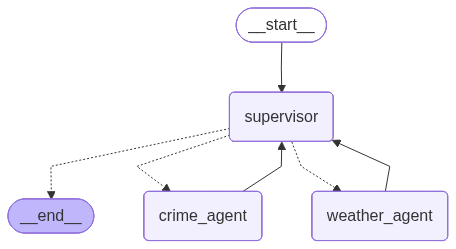

In [45]:
supervisor

In [46]:
response = supervisor.invoke({"messages": [
    HumanMessage(content="""I am a tourist and wanted to find out is it safe to visit Mumbai now""")
]})
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

I am a tourist and wanted to find out is it safe to visit Mumbai now
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_weather_agent (call_lL9utvW8eX1FdI7lp7XC6GQ4)
 Call ID: call_lL9utvW8eX1FdI7lp7XC6GQ4
  Args:
================================= Tool Message =================================
Name: transfer_to_weather_agent

Successfully transferred to weather_agent
================================== Ai Message ==================================
Tool Calls:
  getweahter (call_uEIxFASSkgH5ahwVBTPEZxVb)
 Call ID: call_uEIxFASSkgH5ahwVBTPEZxVb
  Args:
    city: Mumbai
================================= Tool Message =================================
Name: getweahter

{"request": {"type": "City", "query": "Mumbai, India", "language": "en", "unit": "m"}, "location": {"name": "Mumbai", "country": "India", "region": "Maharashtra", "lat": "18

In [26]:
response['messages']

[HumanMessage(content='I am a tourist and wanted to find out is it safe to visit Mumbai now\n    ', additional_kwargs={}, response_metadata={}, id='09b9513a-124e-46df-9be6-e97bdb7afc45'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 143, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CW1ombAgqmKMrucAaBoysur9s0sSm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--cb442a41-1263-4b33-9616-cf04e042552a-0', tool_calls=[{'name': 'transfer_to_weather_agent', 'args': {}, 'id': 'call_lDMTOY0g44qp8IqkS7xRWNwP', 'type': 'tool_call'}], usage_metadata={'input_tokens'